In [1]:
import os
import sys
import shutil
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import mean_img
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_img, plot_roi, plot_design_matrix, plot_contrast_matrix


In [2]:
input_nifti_path = "/lab-share/Neuro-Cohen-e2/Groups/IRB-P00049401/mw_motion_pipeline/runs_and_data/participant_runs/NO_MOTION_CORRECTED_MOTION_INJECTED_p005-ses-04-postrifg_outputs/sub-05_fmriprep_outputs-2026-03-17_13-28-46/ses-03/func/sub-05_ses-03_task-postrifg_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"
input_mask_image = "/lab-share/Neuro-Cohen-e2/Groups/IRB-P00049401/mw_motion_pipeline/runs_and_data/participant_runs/NO_MOTION_CORRECTED_MOTION_INJECTED_p005-ses-04-postrifg_outputs/sub-05_fmriprep_outputs-2026-03-17_13-28-46/ses-03/func/sub-05_ses-03_task-postrifg_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"

event_csv = "/lab-share/Neuro-Cohen-e2/Groups/IRB-P00049401/subject_data/p005/ses-04/realtime_logs_and_events/event_csvs/p005_rifg_task_postRIFG_events_20250826_12h13m39s.csv"

tr: float = 1.06 # must be in s

output_directory = "/lab-share/Neuro-Cohen-e2/Groups/IRB-P00049401/mw_motion_pipeline/runs_and_data/participant_runs/NO_MOTION_CORRECTED_MOTION_INJECTED_p005-ses-04-postrifg_outputs/rIFG_GLM"
os.makedirs(output_directory, exist_ok=True)

In [3]:
nifti_image = nib.load(input_nifti_path)
mask_image = nib.load(input_mask_image)
mean_nifti_image = mean_img(nifti_image)

/tmp/ipykernel_1575048/1918172344.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_nifti_image = mean_img(nifti_image)


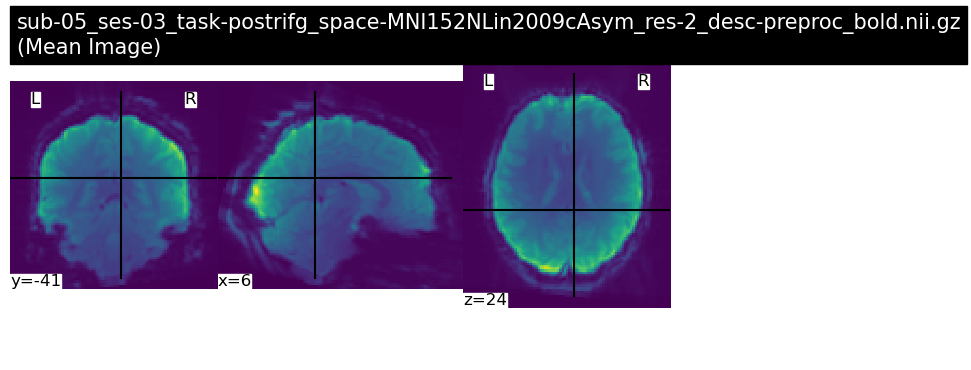

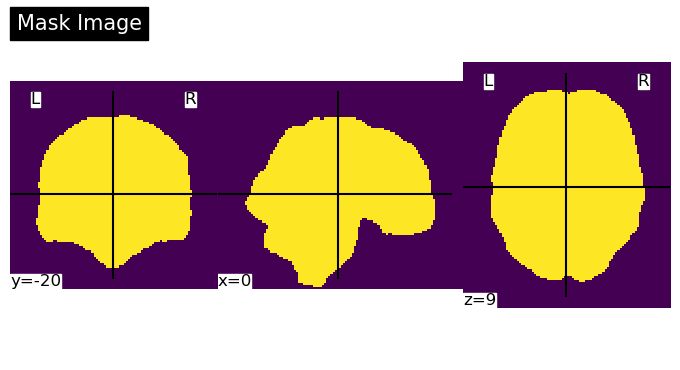

In [4]:
plot_img(
    mean_nifti_image, 
    title=f"{os.path.basename(input_nifti_path)}\n(Mean Image)")

plot_img(
    mask_image, 
    title=f"Mask Image")

In [5]:
events = pd.read_csv(event_csv, delimiter=",")
events.columns = ['onset', 'duration', 'trial_type']
events

,onset,duration,trial_type
0,30.012428,0.5,correct_rejection
1,30.789171,0.5,hit
2,32.327459,0.5,hit
3,33.868272,0.5,hit
4,34.643853,0.5,correct_rejection
...,...,...,...
188,275.652487,0.5,correct_rejection
189,276.939734,0.5,hit
190,278.731890,0.5,hit
191,279.764674,0.5,hit


In [6]:
fmri_glm = FirstLevelModel(
    mask_img=mask_image,
    t_r=tr,
    noise_model="ar1",
    standardize=True,
    hrf_model="spm + derivative",
    drift_model="cosine",
    high_pass=0.01,
    minimize_memory=False,
    smoothing_fwhm=7.2,
    n_jobs=1
)

In [7]:
fmri_glm.fit(
    run_imgs=nifti_image,
    events=events
)

FirstLevelModel(fir_delays=[0], hrf_model='spm + derivative',
                mask_img=<nibabel.nifti1.Nifti1Image object at 0x7fe8cb498bb0>,
                memory=Memory(location=None), minimize_memory=False,
                smoothing_fwhm=7.2, t_r=1.06)

Info On Mask Image:

<class 'nibabel.nifti1.Nifti1Image'>
data shape (97, 115, 97)
affine:
[[   2.     0.     0.   -96.5]
 [   0.     2.     0.  -132.5]
 [   0.     0.     2.   -78.5]
 [   0.     0.     0.     1. ]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3  97 115  97   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'xform matrices modified by FixHeaderApp

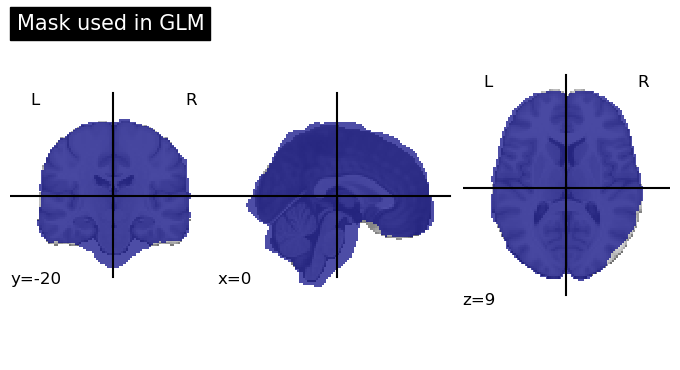

In [8]:
print(f"Info On Mask Image:")
print(fmri_glm.masker_.mask_img_)
plot_roi(fmri_glm.masker_.mask_img_, title="Mask used in GLM")

<Axes: label='conditions', ylabel='scan number'>

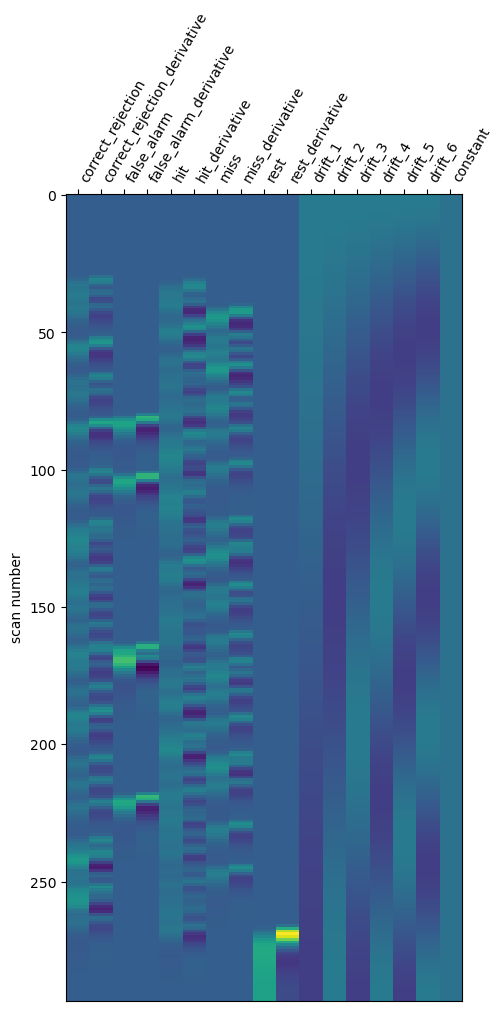

In [9]:
design_matrix = fmri_glm.design_matrices_[0]
plot_design_matrix(design_matrix)


contrast = ((hits - misses) - correct_rejections) - ((hits - misses) - false_alarm)

Contrast Vector: [-1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


<Axes: label='conditions'>

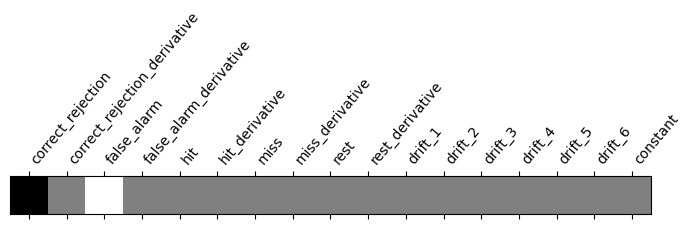

In [10]:

rifg_conditions = ["correct_rejection", "false_alarm", "hit", "miss"]

condition_orders = [
    (design_matrix_column, design_matrix_column_index)
    for design_matrix_column, design_matrix_column_index in enumerate(design_matrix.columns, start=0)
]

contrast_list_at_each_condition = { }
for design_matrix_column, design_matrix_column_index in condition_orders:

        contrast_list_at_each_condition[design_matrix_column_index] = np.zeros(design_matrix.shape[1])

        contrast_list_at_each_condition[design_matrix_column_index][design_matrix_column] = 1

go_trials = []
contrast_vector = []
if not 'hit' in contrast_list_at_each_condition.keys():
        print(f"The RIFG Task GLM Cannot Run When Missing 'run' Trial Types.")
        sys.exit(1)
elif not 'miss' in contrast_list_at_each_condition.keys():
        go_trials = contrast_list_at_each_condition['hit']
else:
        go_trials = contrast_list_at_each_condition['hit'] -  contrast_list_at_each_condition['miss']
if not 'correct_rejection' in contrast_list_at_each_condition.keys():
        if not 'false_alarm' in contrast_list_at_each_condition.keys():
                contrast_vector = go_trials 
        else:
                contrast_vector = go_trials - contrast_list_at_each_condition['false_alarm']
elif not 'false_alarm' in contrast_list_at_each_condition.keys():
        contrast_vector = go_trials - contrast_list_at_each_condition['correct_rejection']
else:
        contrast_vector = (go_trials - contrast_list_at_each_condition['correct_rejection']) - (go_trials - contrast_list_at_each_condition['false_alarm'])

print(f"Contrast Vector: {contrast_vector}")
plot_contrast_matrix(contrast_def=contrast_vector, design_matrix=design_matrix)

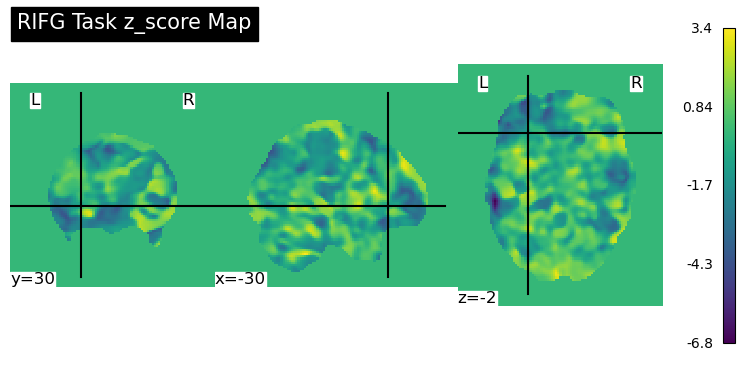

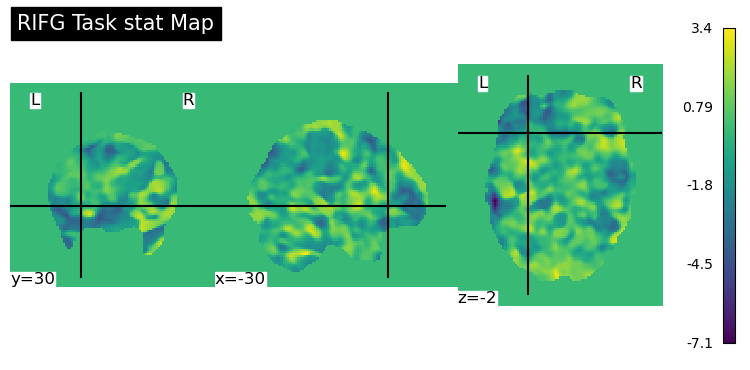

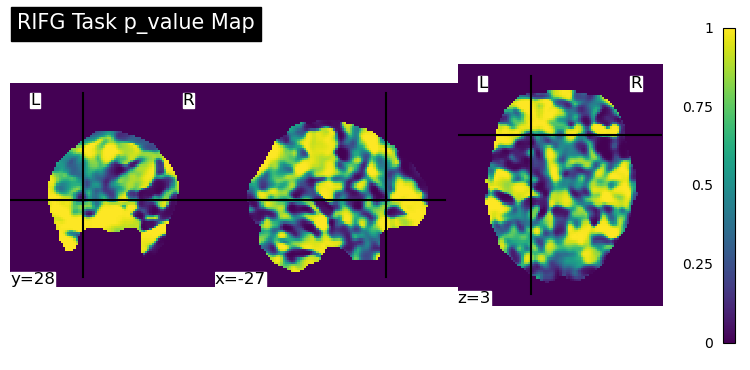

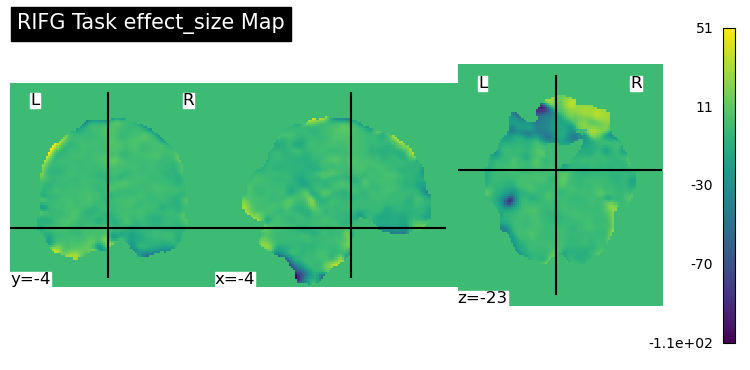

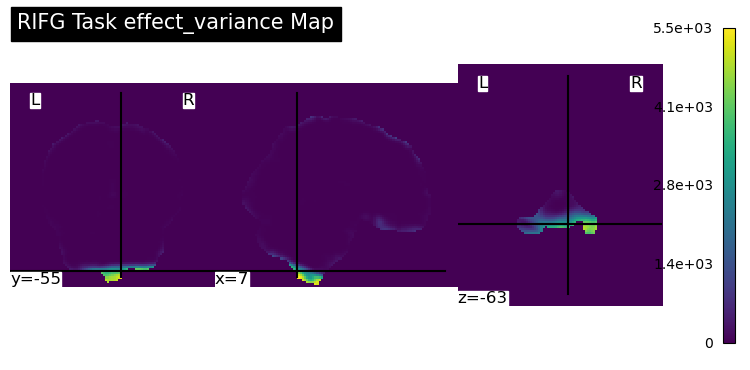

In [11]:
z_maps = fmri_glm.compute_contrast(
    contrast_def=contrast_vector,
    output_type="all"
)

for stat_name, map in z_maps.items():
    
    plot_img(
        map,
        bg_img=mean_nifti_image,
        display_mode='ortho',
        colorbar=True,
        title=f"RIFG Task {stat_name} Map"
    )

    output_plot_path = os.path.join(output_directory, f"{stat_name}.png")
    output_img_path = os.path.join(output_directory, f"{stat_name}.nii.gz")
    plot_img(
        map,
        bg_img=mean_nifti_image,
        display_mode='ortho',
        colorbar=True,
        title=f"RIFG Task {stat_name} Map",
        output_file=output_plot_path)
    nib.save(map, output_img_path)



In [12]:
for file in ("rIFG_GLM.ipynb", event_csv):
    shutil.copy(
        src=file,
        dst=os.path.join(output_directory, os.path.basename(file))
    )